<a href="https://colab.research.google.com/github/BirasaDivine/multimodal-auth-recommendation-system/blob/main/Prediction_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [64]:
import pandas as pd


In [65]:
data1=pd.read_csv("/content/customer_social_profiles - customer_social_profiles.csv")
data2=pd.read_csv("/content/customer_transactions - customer_transactions.csv")
print(data1)
print(data2)

    customer_id_new social_media_platform  engagement_score  \
0              A178              LinkedIn                74   
1              A190               Twitter                82   
2              A150              Facebook                96   
3              A162               Twitter                89   
4              A197               Twitter                92   
..              ...                   ...               ...   
150            A125              LinkedIn                66   
151            A116               Twitter                78   
152            A189               Twitter                59   
153            A162               Twitter                71   
154            A155                TikTok                98   

     purchase_interest_score review_sentiment  
0                        4.9         Positive  
1                        4.8          Neutral  
2                        1.6         Positive  
3                        2.6         Positive  
4  

In [66]:
print(data1.head())
print(data1.isnull().sum())
print(data1.duplicated().sum())

  customer_id_new social_media_platform  engagement_score  \
0            A178              LinkedIn                74   
1            A190               Twitter                82   
2            A150              Facebook                96   
3            A162               Twitter                89   
4            A197               Twitter                92   

   purchase_interest_score review_sentiment  
0                      4.9         Positive  
1                      4.8          Neutral  
2                      1.6         Positive  
3                      2.6         Positive  
4                      2.3          Neutral  
customer_id_new            0
social_media_platform      0
engagement_score           0
purchase_interest_score    0
review_sentiment           0
dtype: int64
5


In [67]:
df1=data1.drop_duplicates()
print(df1.head())
print(df1.duplicated().sum())

  customer_id_new social_media_platform  engagement_score  \
0            A178              LinkedIn                74   
1            A190               Twitter                82   
2            A150              Facebook                96   
3            A162               Twitter                89   
4            A197               Twitter                92   

   purchase_interest_score review_sentiment  
0                      4.9         Positive  
1                      4.8          Neutral  
2                      1.6         Positive  
3                      2.6         Positive  
4                      2.3          Neutral  
0


In [68]:
print(data2.head())
print(data2.isnull().sum())
print(data2.duplicated().sum())

   customer_id_legacy  transaction_id  purchase_amount purchase_date  \
0                 151            1001              408    2024-01-01   
1                 192            1002              332    2024-01-02   
2                 114            1003              442    2024-01-03   
3                 171            1004              256    2024-01-04   
4                 160            1005               64    2024-01-05   

  product_category  customer_rating  
0           Sports              2.3  
1      Electronics              4.2  
2      Electronics              2.1  
3         Clothing              2.8  
4         Clothing              1.3  
customer_id_legacy     0
transaction_id         0
purchase_amount        0
purchase_date          0
product_category       0
customer_rating       10
dtype: int64
0


In [69]:
print(df1['customer_id_new'].head(10))
print(data2['customer_id_legacy'].head(10))

0    A178
1    A190
2    A150
3    A162
4    A197
5    A151
6    A137
7    A196
8    A187
9    A178
Name: customer_id_new, dtype: object
0    151
1    192
2    114
3    171
4    160
5    120
6    182
7    186
8    174
9    174
Name: customer_id_legacy, dtype: int64


In [70]:
df1['customer_id_new'] = df1['customer_id_new'].str.replace('A','').astype(int)

/tmp/ipykernel_168/3561246688.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['customer_id_new'] = df1['customer_id_new'].str.replace('A','').astype(int)


In [71]:
print(df1['customer_id_new'].dtype)
print(df1['customer_id_new'].head(10))
print(data2['customer_id_legacy'].dtype)

int64
0    178
1    190
2    150
3    162
4    197
5    151
6    137
7    196
8    187
9    178
Name: customer_id_new, dtype: int64
int64


In [72]:
print(df1['customer_id_new'].dtype)
print(data2['customer_id_legacy'].dtype)

int64
int64


In [73]:
df=pd.merge(df1,data2, left_on='customer_id_new',right_on='customer_id_legacy', how='inner')
df.head(10)

,customer_id_new,social_media_platform,engagement_score,purchase_interest_score,review_sentiment,customer_id_legacy,transaction_id,purchase_amount,purchase_date,product_category,customer_rating
0,190,Twitter,82,4.8,Neutral,190,1031,333,2024-01-31,Groceries,3.8
1,190,Twitter,82,4.8,Neutral,190,1140,401,2024-05-19,Sports,4.9
2,150,Facebook,96,1.6,Positive,150,1042,389,2024-02-11,Sports,NaN
3,150,Facebook,96,1.6,Positive,150,1046,177,2024-02-15,Books,3.6
4,162,Twitter,89,2.6,Positive,162,1079,101,2024-03-19,Books,4.2
5,162,Twitter,89,2.6,Positive,162,1116,343,2024-04-25,Books,1.4
6,151,TikTok,61,1.3,Neutral,151,1001,408,2024-01-01,Sports,2.3
7,137,LinkedIn,93,3.5,Neutral,137,1020,286,2024-01-20,Electronics,3.2
8,187,LinkedIn,97,4.4,Negative,187,1011,401,2024-01-11,Sports,1.7
9,187,LinkedIn,97,4.4,Negative,187,1018,456,2024-01-18,Groceries,4.8


In [74]:
print(df.shape)


(213, 11)


In [75]:
print(df.columns.tolist())


['customer_id_new', 'social_media_platform', 'engagement_score', 'purchase_interest_score', 'review_sentiment', 'customer_id_legacy', 'transaction_id', 'purchase_amount', 'purchase_date', 'product_category', 'customer_rating']


In [76]:
print(df.head())

   customer_id_new social_media_platform  engagement_score  \
0              190               Twitter                82   
1              190               Twitter                82   
2              150              Facebook                96   
3              150              Facebook                96   
4              162               Twitter                89   

   purchase_interest_score review_sentiment  customer_id_legacy  \
0                      4.8          Neutral                 190   
1                      4.8          Neutral                 190   
2                      1.6         Positive                 150   
3                      1.6         Positive                 150   
4                      2.6         Positive                 162   

   transaction_id  purchase_amount purchase_date product_category  \
0            1031              333    2024-01-31        Groceries   
1            1140              401    2024-05-19           Sports   
2            1042

In [77]:
df = df.drop(columns=['customer_rating', 'transaction_id','customer_id_legacy' ])

In [78]:
print(df.columns.tolist())
print(df.shape)

['customer_id_new', 'social_media_platform', 'engagement_score', 'purchase_interest_score', 'review_sentiment', 'purchase_amount', 'purchase_date', 'product_category']
(213, 8)


In [79]:
print(df.isnull().sum())

customer_id_new            0
social_media_platform      0
engagement_score           0
purchase_interest_score    0
review_sentiment           0
purchase_amount            0
purchase_date              0
product_category           0
dtype: int64


In [80]:
df['purchase_date'] = pd.to_datetime(df['purchase_date'])
df['month'] = df['purchase_date'].dt.month
df['year'] = df['purchase_date'].dt.year
df['dayofweek'] = df['purchase_date'].dt.day_of_week

In [81]:
print(df.head())
print(df.columns.tolist())

   customer_id_new social_media_platform  engagement_score  \
0              190               Twitter                82   
1              190               Twitter                82   
2              150              Facebook                96   
3              150              Facebook                96   
4              162               Twitter                89   

   purchase_interest_score review_sentiment  purchase_amount purchase_date  \
0                      4.8          Neutral              333    2024-01-31   
1                      4.8          Neutral              401    2024-05-19   
2                      1.6         Positive              389    2024-02-11   
3                      1.6         Positive              177    2024-02-15   
4                      2.6         Positive              101    2024-03-19   

  product_category  month  year  dayofweek  
0        Groceries      1  2024          2  
1           Sports      5  2024          6  
2           Sports     

In [82]:
df=df.drop(columns=['purchase_date'])

In [83]:
print(df.columns.tolist())
print(df.head())

['customer_id_new', 'social_media_platform', 'engagement_score', 'purchase_interest_score', 'review_sentiment', 'purchase_amount', 'product_category', 'month', 'year', 'dayofweek']
   customer_id_new social_media_platform  engagement_score  \
0              190               Twitter                82   
1              190               Twitter                82   
2              150              Facebook                96   
3              150              Facebook                96   
4              162               Twitter                89   

   purchase_interest_score review_sentiment  purchase_amount product_category  \
0                      4.8          Neutral              333        Groceries   
1                      4.8          Neutral              401           Sports   
2                      1.6         Positive              389           Sports   
3                      1.6         Positive              177            Books   
4                      2.6         Positi

In [84]:
print(df['product_category'].value_counts())

product_category
Sports         59
Electronics    45
Groceries      38
Books          38
Clothing       33
Name: count, dtype: int64


/tmp/ipykernel_168/732510023.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='product_category', palette='viridis')


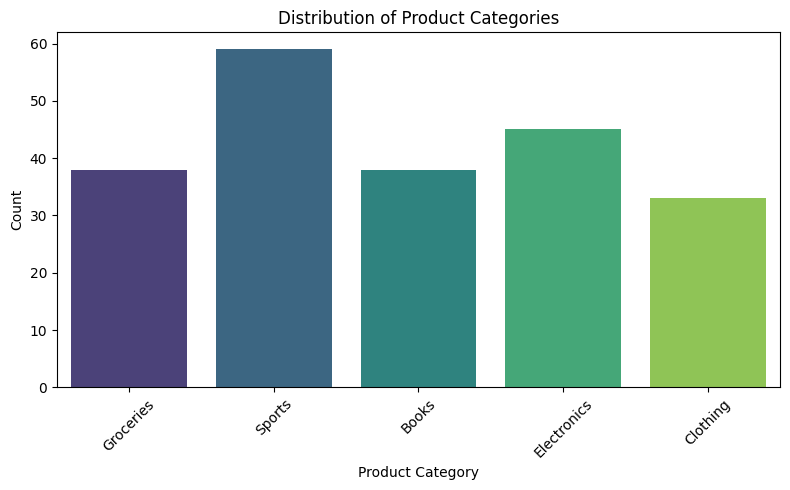

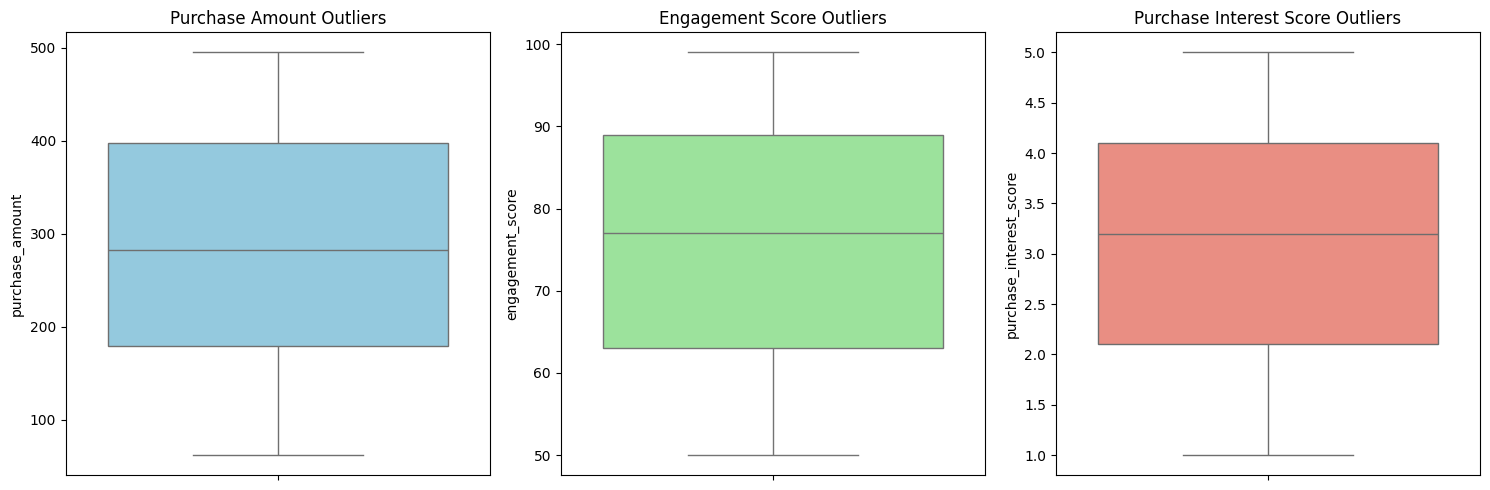

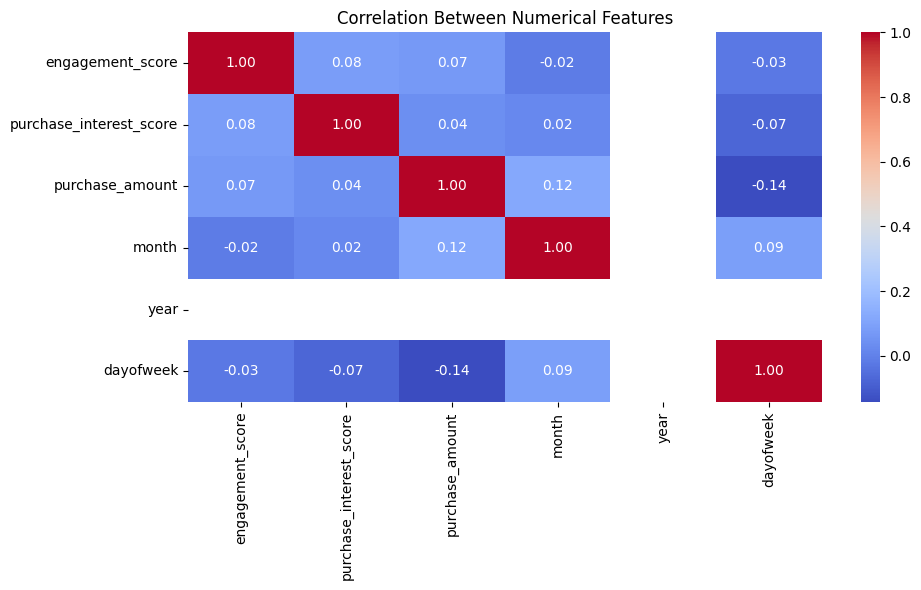

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot 1 - Target Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='product_category', palette='viridis')
plt.title('Distribution of Product Categories')
plt.xlabel('Product Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot 2 - Outlier Detection using Boxplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.boxplot(data=df, y='purchase_amount', ax=axes[0], color='skyblue')
axes[0].set_title('Purchase Amount Outliers')
sns.boxplot(data=df, y='engagement_score', ax=axes[1], color='lightgreen')
axes[1].set_title('Engagement Score Outliers')
sns.boxplot(data=df, y='purchase_interest_score', ax=axes[2], color='salmon')
axes[2].set_title('Purchase Interest Score Outliers')
plt.tight_layout()
plt.show()

# Plot 3 - Correlation Heatmap
plt.figure(figsize=(10, 6))
numerical_cols = ['engagement_score', 'purchase_interest_score',
                  'purchase_amount', 'month', 'year', 'dayofweek']
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Numerical Features')
plt.tight_layout()
plt.show()

In [86]:
plt.savefig('plot_name.png', dpi=150, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [87]:
print(df.columns.tolist())
print(df.shape)

['customer_id_new', 'social_media_platform', 'engagement_score', 'purchase_interest_score', 'review_sentiment', 'purchase_amount', 'product_category', 'month', 'year', 'dayofweek']
(213, 10)


In [88]:
df = pd.get_dummies(df, columns=['social_media_platform'], dtype=int)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['review_sentiment'] = le.fit_transform(df['review_sentiment'])
df['product_category'] = le.fit_transform(df['product_category'])

In [89]:
print(df.columns.tolist())
print(df.head())

['customer_id_new', 'engagement_score', 'purchase_interest_score', 'review_sentiment', 'purchase_amount', 'product_category', 'month', 'year', 'dayofweek', 'social_media_platform_Facebook', 'social_media_platform_Instagram', 'social_media_platform_LinkedIn', 'social_media_platform_TikTok', 'social_media_platform_Twitter']
   customer_id_new  engagement_score  purchase_interest_score  \
0              190                82                      4.8   
1              190                82                      4.8   
2              150                96                      1.6   
3              150                96                      1.6   
4              162                89                      2.6   

   review_sentiment  purchase_amount  product_category  month  year  \
0                 1              333                 3      1  2024   
1                 1              401                 4      5  2024   
2                 2              389                 4      2  2024   
3

In [90]:
print(df['review_sentiment'].unique())
print(df['product_category'].unique())

[1 2 0]
[3 4 0 2 1]


In [91]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cols_to_scale = ['engagement_score', 'purchase_interest_score',
                 'purchase_amount', 'month', 'dayofweek']

df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

In [92]:
print(df[cols_to_scale].describe())

       engagement_score  purchase_interest_score  purchase_amount  \
count      2.130000e+02             2.130000e+02     2.130000e+02   
mean       4.128153e-16            -3.554799e-16    -9.382166e-17   
std        1.002356e+00             1.002356e+00     1.002356e+00   
min       -1.693597e+00            -1.808602e+00    -1.913650e+00   
25%       -8.334409e-01            -8.582644e-01    -9.308155e-01   
50%        9.288067e-02             9.207279e-02    -6.558538e-02   
75%        8.868706e-01             8.696214e-01     9.088486e-01   
max        1.548529e+00             1.647170e+00     1.723677e+00   

              month     dayofweek  
count  2.130000e+02  2.130000e+02  
mean   1.250956e-16 -3.127389e-17  
std    1.002356e+00  1.002356e+00  
min   -1.370718e+00 -1.462229e+00  
25%   -6.772191e-01 -9.516471e-01  
50%    1.627931e-02  6.951579e-02  
75%    7.097777e-01  1.090679e+00  
max    1.403276e+00  1.601260e+00  


In [95]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['product_category'])
y = df['product_category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(170, 13)
(43, 13)


In [97]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

In [98]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print(f'Accuracy: {accuracy:.2f}')
print(f'F1 Score: {f1:.2f}')
print('\nDetailed Report:')
print(classification_report(y_test, y_pred))

Accuracy: 0.40
F1 Score: 0.40

Detailed Report:
              precision    recall  f1-score   support

           0       0.60      0.30      0.40        10
           1       0.20      0.20      0.20         5
           2       0.45      0.50      0.48        10
           3       0.43      0.43      0.43         7
           4       0.33      0.45      0.38        11

    accuracy                           0.40        43
   macro avg       0.40      0.38      0.38        43
weighted avg       0.42      0.40      0.40        43



In [99]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

In [100]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print(f'Accuracy: {accuracy:.2f}')
print(f'F1 Score: {f1:.2f}')
print('\nDetailed Report:')
print(classification_report(y_test, y_pred))

Accuracy: 0.42
F1 Score: 0.41

Detailed Report:
              precision    recall  f1-score   support

           0       0.50      0.30      0.38        10
           1       0.33      0.20      0.25         5
           2       0.46      0.60      0.52        10
           3       0.50      0.29      0.36         7
           4       0.35      0.55      0.43        11

    accuracy                           0.42        43
   macro avg       0.43      0.39      0.39        43
weighted avg       0.43      0.42      0.41        43



In [101]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print(f'CV Scores: {cv_scores}')
print(f'Mean CV Accuracy: {cv_scores.mean():.2f}')
print(f'Std: {cv_scores.std():.2f}')

CV Scores: [0.44186047 0.58139535 0.51162791 0.54761905 0.47619048]
Mean CV Accuracy: 0.51
Std: 0.05


In [103]:
import joblib

# Save the model
joblib.dump(model, 'product_recommendation_model1.pkl')

# Save the merged dataset
df.to_csv('merged_dataset.csv', index=False)

# Save the scaler for later use in the CLI app
joblib.dump(scaler, 'scaler.pkl')

# Save the label encoder
joblib.dump(le, 'label_encoder.pkl')

print("All files saved!")

All files saved!


In [105]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.model_selection import cross_val_score


xgb_model = XGBClassifier(n_estimators=200, max_depth=5, random_state=42, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb, average='weighted')

print(f'Accuracy: {accuracy_xgb:.2f}')
print(f'F1 Score: {f1_xgb:.2f}')
print('\nDetailed Report:')
print(classification_report(y_test, y_pred_xgb))


cv_scores_xgb = cross_val_score(xgb_model, X, y, cv=5, scoring='accuracy')
print(f'CV Scores: {cv_scores_xgb}')
print(f'Mean CV Accuracy: {cv_scores_xgb.mean():.2f}')
print(f'Std: {cv_scores_xgb.std():.2f}')

Accuracy: 0.63
F1 Score: 0.64

Detailed Report:
              precision    recall  f1-score   support

           0       1.00      0.80      0.89        10
           1       1.00      0.40      0.57         5
           2       0.54      0.70      0.61        10
           3       0.40      0.57      0.47         7
           4       0.60      0.55      0.57        11

    accuracy                           0.63        43
   macro avg       0.71      0.60      0.62        43
weighted avg       0.69      0.63      0.64        43

CV Scores: [0.51162791 0.74418605 0.72093023 0.5952381  0.64285714]
Mean CV Accuracy: 0.64
Std: 0.08


In [106]:
import joblib

# Save the best model
joblib.dump(xgb_model, 'product_recommendation_model2.pkl')
joblib.dump(scaler, 'scaler2.pkl')
joblib.dump(le, 'label_encoder2.pkl')
df.to_csv('merged_dataset.csv', index=False)

print("All files saved!")

All files saved!


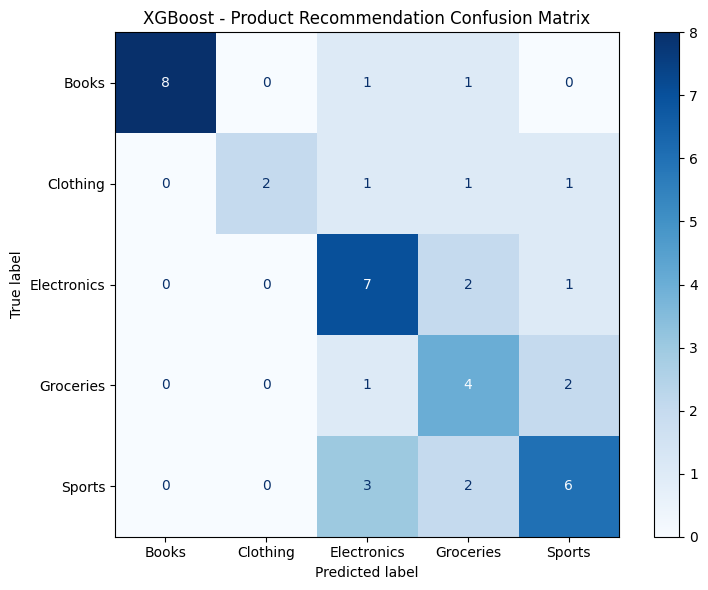

In [107]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Get class names from label encoder
class_names = le.classes_

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', ax=ax)
plt.title('XGBoost - Product Recommendation Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [108]:
print(df.describe())

       customer_id_new  engagement_score  purchase_interest_score  \
count       213.000000      2.130000e+02             2.130000e+02   
mean        147.676056      4.128153e-16            -3.554799e-16   
std          32.325632      1.002356e+00             1.002356e+00   
min         100.000000     -1.693597e+00            -1.808602e+00   
25%         117.000000     -8.334409e-01            -8.582644e-01   
50%         147.000000      9.288067e-02             9.207279e-02   
75%         181.000000      8.868706e-01             8.696214e-01   
max         199.000000      1.548529e+00             1.647170e+00   

       review_sentiment  purchase_amount  product_category         month  \
count        213.000000     2.130000e+02        213.000000  2.130000e+02   
mean           1.107981    -9.382166e-17          2.220657  1.250956e-16   
std            0.825640     1.002356e+00          1.454708  1.002356e+00   
min            0.000000    -1.913650e+00          0.000000 -1.370718e+00  